# Prithvi WxC MERRA-2 O3 Inference

This notebook builds **3-hourly** surface-level O3 forecasts at **t + 3h** using MERRA-2 chemistry fields from `inst3_3d_chm_Nv` and meteorology predictors.

**Key points**
- O3 is a **3D model-level** variable from `inst3_3d_chm_Nv`. We extract the **surface level** (bottom-most valid layer).
- Inputs/targets stay at native **3-hour** resolution (no daily aggregation).
- We map `input_time = t` -> `target_time = t + DELTA_HOURS` (default `DELTA_HOURS = 3`).
- Autoregressive rollout uses previous predicted `O3_sfc` as the next-step O3 input; meteorology stays from each 3-hour MERRA-2 step.


In [1]:
from pathlib import Path
import os
import pandas as pd

# -----------------------------
# Config
# -----------------------------
# Date-time range refers to INPUT timestamps t; targets are t + DELTA_HOURS.
START_TIME = "2020-01-01T00:00:00"
END_TIME = "2020-01-02T21:00:00"
DELTA_HOURS = 3

# Rollout mode: feed previous predicted O3 as next-step O3 input.
AUTOREGRESSIVE_O3 = True

# Resolve base directory robustly, regardless of notebook launch CWD.
def _detect_base_dir():
    cwd = Path.cwd().resolve()

    # Optional explicit override.
    env_base = os.environ.get("MERRA2_PREDICTION_BASE")

    candidates = []
    if env_base:
        candidates.append(Path(env_base))

    # Typical launch locations.
    candidates.extend([
        cwd,
        cwd / "merra2_prediction",
        cwd / "examples" / "merra2_prediction",
    ])

    # Search parent directories for repo-root style layouts.
    for p in [cwd] + list(cwd.parents):
        candidates.append(p / "examples" / "merra2_prediction")

    seen = set()
    checked = []
    for base in candidates:
        base = base.resolve()
        if base in seen:
            continue
        seen.add(base)
        checked.append(str(base))
        if (base / "merra2").exists():
            return base

    raise FileNotFoundError(
        "Could not find merra2_prediction base directory containing 'merra2/'. "
        f"Checked: {checked}. "
        "Set MERRA2_PREDICTION_BASE to the directory containing merra2/, checkpoints/, outputs/ if needed."
    )


BASE_DIR = _detect_base_dir()

# Separate roots/patterns for chemistry (3D) and meteorology (3D in this local sample).
DATA_ROOTS = {
    "chem": BASE_DIR / "merra2",
    "met": BASE_DIR / "merra2",
}
PATTERNS = {
    "chem": "MERRA2_*inst3_3d_chm_N[vV]*.nc4",
    "met": "MERRA2_*inst3_3d_asm_N[vV]*.nc4",
}

# Chemistry variable names in inst3_3d_chm_Nv.
CHEM_VARS = {"O3": "O3"}

# Meteorology variables available in local inst3_3d_asm_Nv sample.
# 3D vars will be reduced to surface level automatically.
MET_VARS = ["T", "U", "V", "PS"]
MET_SUFFIX = "_sfc"

# Output settings.
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FORMAT = "nc"  # "nc" or "zarr"

# Model checkpoint (finetuned model with trained O3 head).
CHECKPOINT_PATH = BASE_DIR / "checkpoints" / "o3_delta3h.ckpt"

# Fallback controls.
# If True and checkpoint is missing, only the pretrained backbone is loaded and the O3 head stays random.
# This produces non-physical output scales. Keep False for real inference.
###Zero-shot pretrained backbone inference is not expected to produce meaningful O3 predictions, but can be useful for testing or as a sanity check.
USE_PRETRAINED_ON_MISSING_CHECKPOINT = True
ALLOW_UNTRAINED_HEAD_INFERENCE = True

#USE_PRETRAINED_ON_MISSING_CHECKPOINT = False
#ALLOW_UNTRAINED_HEAD_INFERENCE = False
PRETRAINED_WEIGHTS_REPO_ID = "ibm-nasa-geospatial/Prithvi-WxC-1.0-2300M"
PRETRAINED_WEIGHTS_FILENAME = "prithvi.wxc.2300m.v1.pt"
PRETRAINED_WEIGHTS_DIR = BASE_DIR / "weights"

# Backbone size. These defaults match Prithvi-WxC-1.0-2300M pretrained weights.
MODEL_EMBED_DIM = 2560
MODEL_N_BLOCKS = 4
MODEL_N_HEADS = 16

# Inference runtime settings.
BATCH_SIZE_PER_GPU = 1
NUM_WORKERS = 0
AMP_MODE = "bf16"  # "bf16" | "fp16" | "no"

# Xarray/netCDF stability settings.
XR_CHUNKS = {"time": 8, "lat": 181, "lon": 288}

# Optional tiling fallback for large HxW (OOM safety).
ENABLE_TILING = True
TILE_SIZE = 256
TILE_OVERLAP = 32

assert DELTA_HOURS >= 1
assert isinstance(AUTOREGRESSIVE_O3, bool)
assert isinstance(ALLOW_UNTRAINED_HEAD_INFERENCE, bool)
assert AMP_MODE in {"bf16", "fp16", "no"}


In [2]:
# Variable mapping table (user-editable).
var_map = pd.DataFrame([
    {"role": "predictor", "dataset": "inst3_3d_chm_Nv", "varname": "O3", "notes": "3D -> surface"},
    {"role": "predictor", "dataset": "inst3_2d_asm_Nx", "varname": "T2M", "notes": "2D met"},
    {"role": "predictor", "dataset": "inst3_2d_asm_Nx", "varname": "U10M", "notes": "2D met"},
    {"role": "predictor", "dataset": "inst3_2d_asm_Nx", "varname": "V10M", "notes": "2D met"},
    {"role": "predictor", "dataset": "inst3_2d_asm_Nx", "varname": "PS", "notes": "2D met"},
    {"role": "target", "dataset": "inst3_3d_chm_Nv", "varname": "O3", "notes": "surface, t+3h"},
])
var_map


,role,dataset,varname,notes
0,predictor,inst3_3d_chm_Nv,O3,3D -> surface
1,predictor,inst3_2d_asm_Nx,T2M,2D met
2,predictor,inst3_2d_asm_Nx,U10M,2D met
3,predictor,inst3_2d_asm_Nx,V10M,2D met
4,predictor,inst3_2d_asm_Nx,PS,2D met
5,target,inst3_3d_chm_Nv,O3,"surface, t+3h"


In [3]:
import torch

n_gpus = torch.cuda.device_count()
print(f"GPUs detected: {n_gpus}")
if n_gpus > 0:
    for i in range(n_gpus):
        print(i, torch.cuda.get_device_name(i))
    bf16_ok = torch.cuda.is_bf16_supported()
    if AMP_MODE == "bf16" and not bf16_ok:
        print("bf16 not supported; falling back to fp16")
        AMP_MODE = "fp16"


GPUs detected: 4
0 NVIDIA A10G
1 NVIDIA A10G
2 NVIDIA A10G
3 NVIDIA A10G


In [4]:
import glob
import importlib.util
import numpy as np
import pandas as pd
import xarray as xr

def resolve_paths(root, pattern):
    root = Path(root)
    paths = sorted(glob.glob(str(root / pattern)))
    if not paths:
        raise FileNotFoundError(f"No files match {root / pattern}")
    return paths

def _pick_engine():
    # Prefer h5netcdf for notebook stability; fall back to netcdf4.
    return "h5netcdf" if importlib.util.find_spec("h5netcdf") is not None else "netcdf4"

def _to_utc_naive(ts):
    t = pd.to_datetime(ts, utc=True)
    return t.tz_convert(None)

def open_mfdataset_utc(paths, vars_to_keep=None):
    ds = xr.open_mfdataset(
        paths,
        combine="by_coords",
        decode_times=True,
        parallel=False,
        engine=_pick_engine(),
        chunks=XR_CHUNKS,
    )
    if vars_to_keep is not None:
        missing = [v for v in vars_to_keep if v not in ds.data_vars]
        if missing:
            raise KeyError(f"Missing variables {missing}. Available sample: {list(ds.data_vars)[:20]}")
        ds = ds[vars_to_keep]

    # MERRA-2 timestamps are UTC; normalize to tz-naive UTC datetime64.
    ds = ds.sortby("time")
    t = pd.to_datetime(ds.time.values, utc=True).tz_convert(None)
    ds = ds.assign_coords(time=t)

    start_in = _to_utc_naive(START_TIME)
    end_in = _to_utc_naive(END_TIME)
    if end_in < start_in:
        raise ValueError(f"END_TIME ({END_TIME}) must be >= START_TIME ({START_TIME})")

    # Include enough timestamps to build targets at t + DELTA_HOURS.
    end_target = end_in + pd.Timedelta(hours=DELTA_HOURS)
    ds = ds.sel(time=slice(start_in, end_target))
    return ds

def _find_vertical_dim(da_3d, candidates):
    for dim in candidates:
        if dim in da_3d.dims:
            return dim
    raise ValueError(f"No vertical dim found in {da_3d.dims}")

def extract_surface_3d(da_3d, lev_dim_candidates=["lev", "level", "model_level", "eta", "pfull"]):
    """
    Extract the bottom-most (surface) layer from a 3D field.
    Strategy: prefer the index corresponding to the maximum vertical coordinate value
    (pressure-like coordinates are larger near the surface). Fall back to last index.
    """
    lev_dim = _find_vertical_dim(da_3d, lev_dim_candidates)
    coord = da_3d[lev_dim]
    idx = coord.size - 1
    if np.issubdtype(coord.dtype, np.number) and coord.size > 0:
        vals = coord.values
        positive = str(coord.attrs.get("positive", "")).lower()
        if np.all(np.isnan(vals)):
            idx = coord.size - 1
        elif positive == "up":
            idx = int(np.nanargmin(vals))
        elif positive == "down":
            idx = int(np.nanargmax(vals))
        else:
            idx = int(np.nanargmax(vals))
    da_sfc = da_3d.isel({lev_dim: idx}).copy()
    da_sfc.attrs = dict(da_3d.attrs)
    if da_3d.name:
        da_sfc.attrs["long_name"] = f"{da_3d.name} surface (bottom-most model level)"
    return da_sfc

def load_chem_3d():
    # Load 3-hourly 3D chemistry and extract surface.
    paths = resolve_paths(DATA_ROOTS["chem"], PATTERNS["chem"])
    ds = open_mfdataset_utc(paths, vars_to_keep=list(CHEM_VARS.values()))
    o3 = extract_surface_3d(ds[CHEM_VARS["O3"]]).rename("O3_sfc")
    return xr.Dataset({"O3_sfc": o3})

def load_met_3h():
    # Load met fields and map all channels to <var><MET_SUFFIX> names.
    paths = resolve_paths(DATA_ROOTS["met"], PATTERNS["met"])
    ds = open_mfdataset_utc(paths, vars_to_keep=MET_VARS)
    ds_surface = xr.Dataset()
    for v in MET_VARS:
        da = ds[v]
        if any(dim in da.dims for dim in ["lev", "level", "model_level", "eta", "pfull"]):
            ds_surface[f"{v}{MET_SUFFIX}"] = extract_surface_3d(da)
        else:
            ds_surface[f"{v}{MET_SUFFIX}"] = da
    return ds_surface

def build_inputs_targets_3h(ds_met_3h, ds_chem_3h):
    # Predictors at time t.
    ds_predictors_3h = xr.merge([ds_chem_3h[["O3_sfc"]], ds_met_3h])
    o3_3h = ds_chem_3h["O3_sfc"]

    if DELTA_HOURS < 1:
        raise ValueError("DELTA_HOURS must be >= 1")

    t_in = pd.DatetimeIndex(ds_predictors_3h.time.values)
    t_out = t_in + pd.Timedelta(hours=DELTA_HOURS)
    t_target = pd.DatetimeIndex(o3_3h.time.values)

    valid = t_out.isin(t_target)
    if not valid.any():
        raise ValueError(
            "No valid input/target pairs found for DELTA_HOURS. "
            "Check START_TIME/END_TIME coverage and source file range."
        )

    t_in_valid = t_in[valid]
    t_out_valid = t_out[valid]

    ds_predictors_3h = ds_predictors_3h.sel(time=t_in_valid)
    o3_target_3h = o3_3h.sel(time=t_out_valid).assign_coords(time=t_in_valid)

    ds_predictors_3h, o3_target_3h = xr.align(ds_predictors_3h, o3_target_3h, join="inner")
    time_out = xr.DataArray(
        t_out_valid.values.astype("datetime64[ns]"),
        dims=["time"],
        coords={"time": t_in_valid.values},
        name="time_out",
    )
    return ds_predictors_3h, o3_target_3h, time_out


In [5]:
ds_chem_3h = load_chem_3d()
ds_met_3h = load_met_3h()

# Align spatial grid and time indices across chem/met.
ds_chem_3h, ds_met_3h = xr.align(ds_chem_3h, ds_met_3h, join="inner")

ds_inputs_3h, da_target_3h, time_out = build_inputs_targets_3h(ds_met_3h, ds_chem_3h)

print(ds_inputs_3h)
print(da_target_3h)
print(f"3-hourly samples: {ds_inputs_3h.sizes.get('time', 0)}")


/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp

<xarray.Dataset> Size: 67MB
Dimensions:  (time: 16, lat: 361, lon: 576)
Coordinates:
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
    lev      float64 8B 72.0
  * time     (time) datetime64[ns] 128B 2020-01-01 ... 2020-01-02T21:00:00
Data variables:
    O3_sfc   (time, lat, lon) float32 13MB dask.array<chunksize=(5, 181, 288), meta=np.ndarray>
    T_sfc    (time, lat, lon) float32 13MB dask.array<chunksize=(5, 181, 288), meta=np.ndarray>
    U_sfc    (time, lat, lon) float32 13MB dask.array<chunksize=(5, 181, 288), meta=np.ndarray>
    V_sfc    (time, lat, lon) float32 13MB dask.array<chunksize=(5, 181, 288), meta=np.ndarray>
    PS_sfc   (time, lat, lon) float32 13MB dask.array<chunksize=(5, 181, 288), meta=np.ndarray>
<xarray.DataArray 'O3_sfc' (time: 16, lat: 361, lon: 576)> Size: 13MB
dask.array<getitem, shape=(16, 361, 576), dtype=float32, chunksize=(6, 181, 288), chu

/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(


In [6]:
from torch.utils.data import Dataset, DataLoader

class Merra2Dataset3H(Dataset):
    def __init__(self, ds_inputs, time_out):
        self.ds_inputs = ds_inputs
        self.time_out = time_out
        self.predictors = list(ds_inputs.data_vars)
        # Stack predictors into a (time, channel, lat, lon) view.
        self.stacked = ds_inputs.to_array().transpose("time", "variable", "lat", "lon")
        self.time_out_ns = self.time_out.values.astype("datetime64[ns]").astype("int64")

    def __len__(self):
        return self.stacked.sizes["time"]

    def __getitem__(self, idx):
        x = self.stacked.isel(time=idx).values.astype("float32")
        return {
            "x": torch.from_numpy(x),
            "idx": torch.tensor(idx, dtype=torch.int64),
            "time_out": torch.tensor(self.time_out_ns[idx], dtype=torch.int64),
        }

dataset = Merra2Dataset3H(ds_inputs_3h, time_out)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE_PER_GPU,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Predictor order: {dataset.predictors}")


Predictor order: ['O3_sfc', 'T_sfc', 'U_sfc', 'V_sfc', 'PS_sfc']


In [7]:
import torch.nn as nn
import torch.nn.functional as F
from huggingface_hub import hf_hub_download

try:
    from PrithviWxC.model import PrithviWxCEncoderDecoder
except Exception as e:
    raise ImportError("PrithviWxC is required. Install the package before running this notebook.") from e

class O3Delta1Model(nn.Module):
    """
    Minimal wrapper: Prithvi-WxC backbone + 1x1 conv head for O3_sfc.
    If you do not have a finetuned checkpoint, a pretrained backbone is loaded.

    Notes:
    - PrithviWxCEncoderDecoder expects tokens shaped
      [B, global_seq, local_seq, embed_dim].
    - We use mask units of size mask_unit_size in pixel space and pad inputs
      so arbitrary HxW can be handled.
    """
    def __init__(self, in_channels, embed_dim=128, n_blocks=4, n_heads=4, mask_unit_size=(16, 16)):
        super().__init__()

        if len(mask_unit_size) != 2:
            raise ValueError(f"mask_unit_size must be length 2, got {mask_unit_size}")
        self.mask_unit_size = (int(mask_unit_size[0]), int(mask_unit_size[1]))
        if self.mask_unit_size[0] <= 0 or self.mask_unit_size[1] <= 0:
            raise ValueError(f"mask_unit_size must be positive, got {self.mask_unit_size}")

        self.backbone = PrithviWxCEncoderDecoder(
            embed_dim=embed_dim,
            n_blocks=n_blocks,
            mlp_multiplier=4,
            n_heads=n_heads,
            dropout=0.0,
            drop_path=0.0,
        )
        self.proj = nn.Conv2d(embed_dim, 1, kernel_size=1)
        self.in_proj = nn.Conv2d(in_channels, embed_dim, kernel_size=1)

    @staticmethod
    def _pad_to_multiple(x, multiple_hw):
        _, _, h, w = x.shape
        mh, mw = multiple_hw
        pad_h = (mh - (h % mh)) % mh
        pad_w = (mw - (w % mw)) % mw
        if pad_h or pad_w:
            x = F.pad(x, (0, pad_w, 0, pad_h), mode="replicate")
        return x, pad_h, pad_w

    def _to_tokens(self, x):
        # [B, E, H, W] -> [B, global_seq, local_seq, E]
        b, e, h, w = x.shape
        mu_h, mu_w = self.mask_unit_size

        if h % mu_h != 0 or w % mu_w != 0:
            raise ValueError(
                f"Input size {(h, w)} not divisible by mask_unit_size {self.mask_unit_size}."
            )

        g_h, g_w = h // mu_h, w // mu_w
        x_tokens = (
            x.reshape(b, e, g_h, mu_h, g_w, mu_w)
            .permute(0, 2, 4, 3, 5, 1)
            .flatten(3, 4)
            .flatten(1, 2)
        )
        return x_tokens, (g_h, g_w, mu_h, mu_w)

    @staticmethod
    def _from_tokens(x_tokens, token_shape):
        # [B, global_seq, local_seq, E] -> [B, E, H, W]
        g_h, g_w, l_h, l_w = token_shape
        b = x_tokens.shape[0]
        x = (
            x_tokens.reshape(b, g_h, g_w, l_h, l_w, -1)
            .permute(0, 5, 1, 3, 2, 4)
            .flatten(4, 5)
            .flatten(2, 3)
        )
        return x

    def forward(self, x):
        # x: (B, C, H, W)
        h_orig, w_orig = x.shape[-2], x.shape[-1]

        x = self.in_proj(x)
        x, _, _ = self._pad_to_multiple(x, self.mask_unit_size)

        x_tokens, token_shape = self._to_tokens(x)
        feat_tokens = self.backbone(x_tokens)
        feat = self._from_tokens(feat_tokens, token_shape)

        # Remove any spatial padding added before tokenization.
        feat = feat[..., :h_orig, :w_orig]

        out = self.proj(feat)
        return out


def _normalize_state_dict(state_dict):
    # Support checkpoints wrapped in common containers.
    if not isinstance(state_dict, dict):
        raise TypeError(f"Expected dict-like checkpoint, got {type(state_dict)}")

    for wrap_key in ("model_state", "state_dict", "model", "module"):
        if wrap_key in state_dict and isinstance(state_dict[wrap_key], dict):
            state_dict = state_dict[wrap_key]

    # Keep tensor entries only (ignore metadata scalars/strings).
    state_dict = {k: v for k, v in state_dict.items() if torch.is_tensor(v)}
    return state_dict


def _extract_backbone_state_dict(state_dict, backbone):
    backbone_keys = set(backbone.state_dict().keys())

    def _candidates(k):
        out = [k]

        # Strip common prefixes used by training wrappers.
        for p in (
            "module.",
            "model.",
            "backbone.",
            "encoder.",
            "encoder_decoder.",
            "net.",
            "core.",
            "base_model.",
        ):
            if k.startswith(p):
                out.append(k[len(p):])

        parts = k.split(".")

        # Try dropping leading path segments (useful when checkpoints add extra hierarchy).
        for i in range(1, min(8, len(parts))):
            out.append(".".join(parts[i:]))

        # Explicitly drop segment starting at backbone/encoder_decoder when present.
        for i, part in enumerate(parts):
            if part in {"backbone", "encoder_decoder", "encoder"} and i + 1 < len(parts):
                out.append(".".join(parts[i + 1:]))

        # Deduplicate while preserving order.
        seen = set()
        uniq = []
        for cand in out:
            if cand not in seen:
                uniq.append(cand)
                seen.add(cand)
        return uniq

    mapped = {}
    for k, v in state_dict.items():
        for cand in _candidates(k):
            if cand in backbone_keys:
                mapped[cand] = v
                break

    return mapped


model = O3Delta1Model(
    in_channels=len(dataset.predictors),
    embed_dim=MODEL_EMBED_DIM,
    n_blocks=MODEL_N_BLOCKS,
    n_heads=MODEL_N_HEADS,
)
ckpt_path = Path(CHECKPOINT_PATH)
model_has_trained_head = ckpt_path.is_file()

if ckpt_path.is_file():
    ckpt = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
    ckpt = _normalize_state_dict(ckpt)
    missing, unexpected = model.load_state_dict(ckpt, strict=False)
    print(f"Loaded fine-tuned checkpoint: {ckpt_path}")
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)
else:
    if not USE_PRETRAINED_ON_MISSING_CHECKPOINT:
        raise FileNotFoundError(
            f"Checkpoint not found at {ckpt_path} and pretrained fallback is disabled."
        )

    PRETRAINED_WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
    weights_path = PRETRAINED_WEIGHTS_DIR / PRETRAINED_WEIGHTS_FILENAME
    hf_hub_download(
        repo_id=PRETRAINED_WEIGHTS_REPO_ID,
        filename=PRETRAINED_WEIGHTS_FILENAME,
        local_dir=str(PRETRAINED_WEIGHTS_DIR),
    )

    state_dict = torch.load(str(weights_path), map_location="cpu", weights_only=False)
    state_dict = _normalize_state_dict(state_dict)
    backbone_state = _extract_backbone_state_dict(state_dict, model.backbone)

    if not backbone_state:
        print("WARNING: Downloaded pretrained weights could not be mapped to PrithviWxCEncoderDecoder.")
        print("Continuing with randomly initialized backbone and head.")
        print("Checkpoint key sample:", list(state_dict.keys())[:12])
        print("Backbone key sample:", list(model.backbone.state_dict().keys())[:12])
    else:
        model_backbone_sd = model.backbone.state_dict()
        compatible = {
            k: v for k, v in backbone_state.items()
            if k in model_backbone_sd and tuple(v.shape) == tuple(model_backbone_sd[k].shape)
        }
        skipped = len(backbone_state) - len(compatible)

        missing, unexpected = model.backbone.load_state_dict(compatible, strict=False)
        print(f"Loaded pretrained backbone from: {weights_path}")
        print(f"Mapped {len(compatible)} tensors into backbone.")
        print(f"Skipped {skipped} tensors due to shape mismatch.")
        print("Backbone missing keys:", missing)
        print("Backbone unexpected keys:", unexpected)
        print("Head remains randomly initialized (proj/in_proj).")

if (not model_has_trained_head) and (not ALLOW_UNTRAINED_HEAD_INFERENCE):
    raise RuntimeError(
        "No fine-tuned checkpoint found, so the O3 head is untrained and outputs are not physically meaningful. "
        "Set CHECKPOINT_PATH to a real fine-tuned checkpoint or set ALLOW_UNTRAINED_HEAD_INFERENCE=True "
        "only for architecture/debug checks."
    )


/mnt/data2/kyo/.mamba/envs/Prithvi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded pretrained backbone from: /mnt/data2/kyo/granite-wxc/examples/merra2_prediction/weights/prithvi.wxc.2300m.v1.pt
Mapped 90 tensors into backbone.
Skipped 0 tensors due to shape mismatch.
Backbone missing keys: []
Backbone unexpected keys: []
Head remains randomly initialized (proj/in_proj).


In [8]:
try:
    from accelerate import Accelerator
    USE_ACCELERATE = True
except ImportError:
    Accelerator = None
    USE_ACCELERATE = False
    print("accelerate not installed; using single-process PyTorch inference.")

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(iterable=None, **kwargs):
        return iterable
    print("tqdm not installed; progress bars disabled.")


def tile_inference(model, x, tile_size, overlap):
    # Simple tiling fallback for large HxW.
    b, c, h, w = x.shape
    out = torch.zeros((b, 1, h, w), device=x.device, dtype=x.dtype)
    weight = torch.zeros((1, 1, h, w), device=x.device, dtype=x.dtype)
    stride = tile_size - overlap
    for y in range(0, h, stride):
        for z in range(0, w, stride):
            y0, y1 = y, min(y + tile_size, h)
            z0, z1 = z, min(z + tile_size, w)
            tile = x[:, :, y0:y1, z0:z1]
            pred = model(tile)
            out[:, :, y0:y1, z0:z1] += pred
            weight[:, :, y0:y1, z0:z1] += 1
    return out / weight


# Autoregressive rollout is sequential in time, so we run single-process.
if AUTOREGRESSIVE_O3 and USE_ACCELERATE:
    print("AUTOREGRESSIVE_O3=True: using sequential single-process rollout.")

if USE_ACCELERATE and not AUTOREGRESSIVE_O3:
    accelerator = Accelerator(mixed_precision=None if AMP_MODE == "no" else AMP_MODE)
    device = accelerator.device
    model, dataloader = accelerator.prepare(model, dataloader)
    is_main_process = accelerator.is_main_process
else:
    accelerator = None
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    is_main_process = True

model.eval()

preds_all = []
idx_all = []
time_out_all = []

with torch.no_grad():
    if AUTOREGRESSIVE_O3:
        if "O3_sfc" not in dataset.predictors:
            raise KeyError(f"O3_sfc not found in predictors: {dataset.predictors}")

        o3_channel = dataset.predictors.index("O3_sfc")
        prev_pred = None  # Prediction at current input time for rollout continuation.

        step_iter = tqdm(
            range(len(dataset)),
            total=len(dataset),
            desc="Inference (AR)",
            dynamic_ncols=True,
            disable=not is_main_process,
        )
        for i in step_iter:
            sample = dataset[i]
            x = sample["x"].unsqueeze(0).to(device, non_blocking=True)  # [1, C, H, W]

            # Replace O3 input with previous prediction for autoregressive rollout.
            if prev_pred is not None:
                x[:, o3_channel, :, :] = prev_pred

            if x.is_cuda:
                x = x.contiguous(memory_format=torch.channels_last)

            if ENABLE_TILING:
                y = tile_inference(model, x, TILE_SIZE, TILE_OVERLAP)
            else:
                y = model(x)

            y = y.squeeze(1)  # [1, H, W]
            prev_pred = y.detach()

            preds_all.append(y.cpu())
            idx_all.append(sample["idx"].view(1).cpu())
            time_out_all.append(sample["time_out"].view(1).cpu())
    else:
        total_batches = len(dataloader) if hasattr(dataloader, "__len__") else None
        batch_iter = tqdm(
            dataloader,
            total=total_batches,
            desc="Inference (batched)",
            dynamic_ncols=True,
            disable=(accelerator is not None and not is_main_process),
        )
        for batch in batch_iter:
            x = batch["x"].to(device, non_blocking=True)
            if x.is_cuda:
                x = x.contiguous(memory_format=torch.channels_last)

            if ENABLE_TILING:
                y = tile_inference(model, x, TILE_SIZE, TILE_OVERLAP)
            else:
                y = model(x)

            y = y.squeeze(1)

            if accelerator is not None:
                # Gather predictions + indices from all ranks for deterministic ordering.
                y_g = accelerator.gather(y)
                idx_g = accelerator.gather(batch["idx"].to(device))
                time_g = accelerator.gather(batch["time_out"].to(device))

                if is_main_process:
                    preds_all.append(y_g.cpu())
                    idx_all.append(idx_g.cpu())
                    time_out_all.append(time_g.cpu())
            else:
                preds_all.append(y.cpu())
                idx_all.append(batch["idx"].cpu())
                time_out_all.append(batch["time_out"].cpu())

if accelerator is not None:
    accelerator.wait_for_everyone()

if is_main_process:
    preds_all = torch.cat(preds_all, dim=0)
    idx_all = torch.cat(idx_all, dim=0).numpy()
    time_out_all = torch.cat(time_out_all, dim=0).numpy()

    order = np.argsort(idx_all)
    preds_all = preds_all[order]  # (time, H, W)
    time_out_all = time_out_all[order]

    print("Predictions shape:", preds_all.shape)


accelerate not installed; using single-process PyTorch inference.


Inference (AR): 100%|██████████| 16/16 [05:50<00:00, 21.88s/it]

Predictions shape: torch.Size([16, 361, 576])


In [9]:
import os
if is_main_process:
    time_out_dt = time_out_all.astype("datetime64[ns]")
    start_tag = pd.to_datetime(time_out_dt[0]).strftime("%Y%m%dT%H%M")
    end_tag = pd.to_datetime(time_out_dt[-1]).strftime("%Y%m%dT%H%M")

    # Materialize arrays to detach output from lazily-backed input files.
    preds_np = preds_all.numpy().astype("float32", copy=False)
    lat_np = np.asarray(ds_inputs_3h["lat"].values)
    lon_np = np.asarray(ds_inputs_3h["lon"].values)

    ds_out = xr.Dataset(
        {"O3_sfc": (("time_out", "lat", "lon"), preds_np)},
        coords={
            "time_out": time_out_dt,
            "lat": lat_np,
            "lon": lon_np,
        },
    ).load()
    ds_out["O3_sfc"].attrs["long_name"] = f"Surface O3 forecast (t+{DELTA_HOURS}h)"
    src_units = ds_chem_3h["O3_sfc"].attrs.get("units", "") if "O3_sfc" in ds_chem_3h else ""
    if src_units:
        ds_out["O3_sfc"].attrs["units"] = src_units
    ds_out.attrs.update({
        "source": "MERRA-2 inst3_3d_chm_Nv",
        "input_temporal_resolution": "3-hourly",
        "delta_hours": DELTA_HOURS,
        "predictors": ",".join(dataset.predictors),
    })

    out_name = f"o3_sfc_delta{DELTA_HOURS}h_{start_tag}_{end_tag}.{OUTPUT_FORMAT}"
    out_path = OUTPUT_DIR / out_name

    if OUTPUT_FORMAT == "nc":
        os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")
        tmp_path = out_path.with_suffix(out_path.suffix + ".tmp")
        if tmp_path.exists():
            tmp_path.unlink()

        engines = []
        preferred = _pick_engine()
        if preferred is not None:
            engines.append(preferred)
        for eng in ("netcdf4", "h5netcdf", "scipy"):
            if eng not in engines:
                engines.append(eng)

        last_err = None
        print(f"Writing netCDF to {out_path.resolve()} using engines={engines}")
        for eng in engines:
            try:
                print(f"Attempting netCDF write with engine={eng} ...")
                if eng == "scipy":
                    ds_out.to_netcdf(tmp_path, engine=eng, mode="w")
                else:
                    ds_out.to_netcdf(tmp_path, engine=eng, mode="w", format="NETCDF4")
                tmp_path.replace(out_path)
                print(f"Wrote {out_path} (engine={eng})")
                last_err = None
                break
            except Exception as e:
                last_err = e
                if tmp_path.exists():
                    tmp_path.unlink()

        if last_err is not None:
            raise RuntimeError(
                f"Failed to write netCDF after trying engines {engines}. "
                "Try OUTPUT_FORMAT='zarr' as fallback."
            ) from last_err

    elif OUTPUT_FORMAT == "zarr":
        ds_out.to_zarr(out_path, mode="w")
        print("Wrote", out_path)
    else:
        raise ValueError('OUTPUT_FORMAT must be "nc" or "zarr"')


Writing netCDF to /mnt/data2/kyo/granite-wxc/examples/merra2_prediction/outputs/o3_sfc_delta3h_20200101T0300_20200103T0000.nc using engines=['h5netcdf', 'netcdf4', 'scipy']
Attempting netCDF write with engine=h5netcdf ...
Wrote /mnt/data2/kyo/granite-wxc/examples/merra2_prediction/outputs/o3_sfc_delta3h_20200101T0300_20200103T0000.nc (engine=h5netcdf)


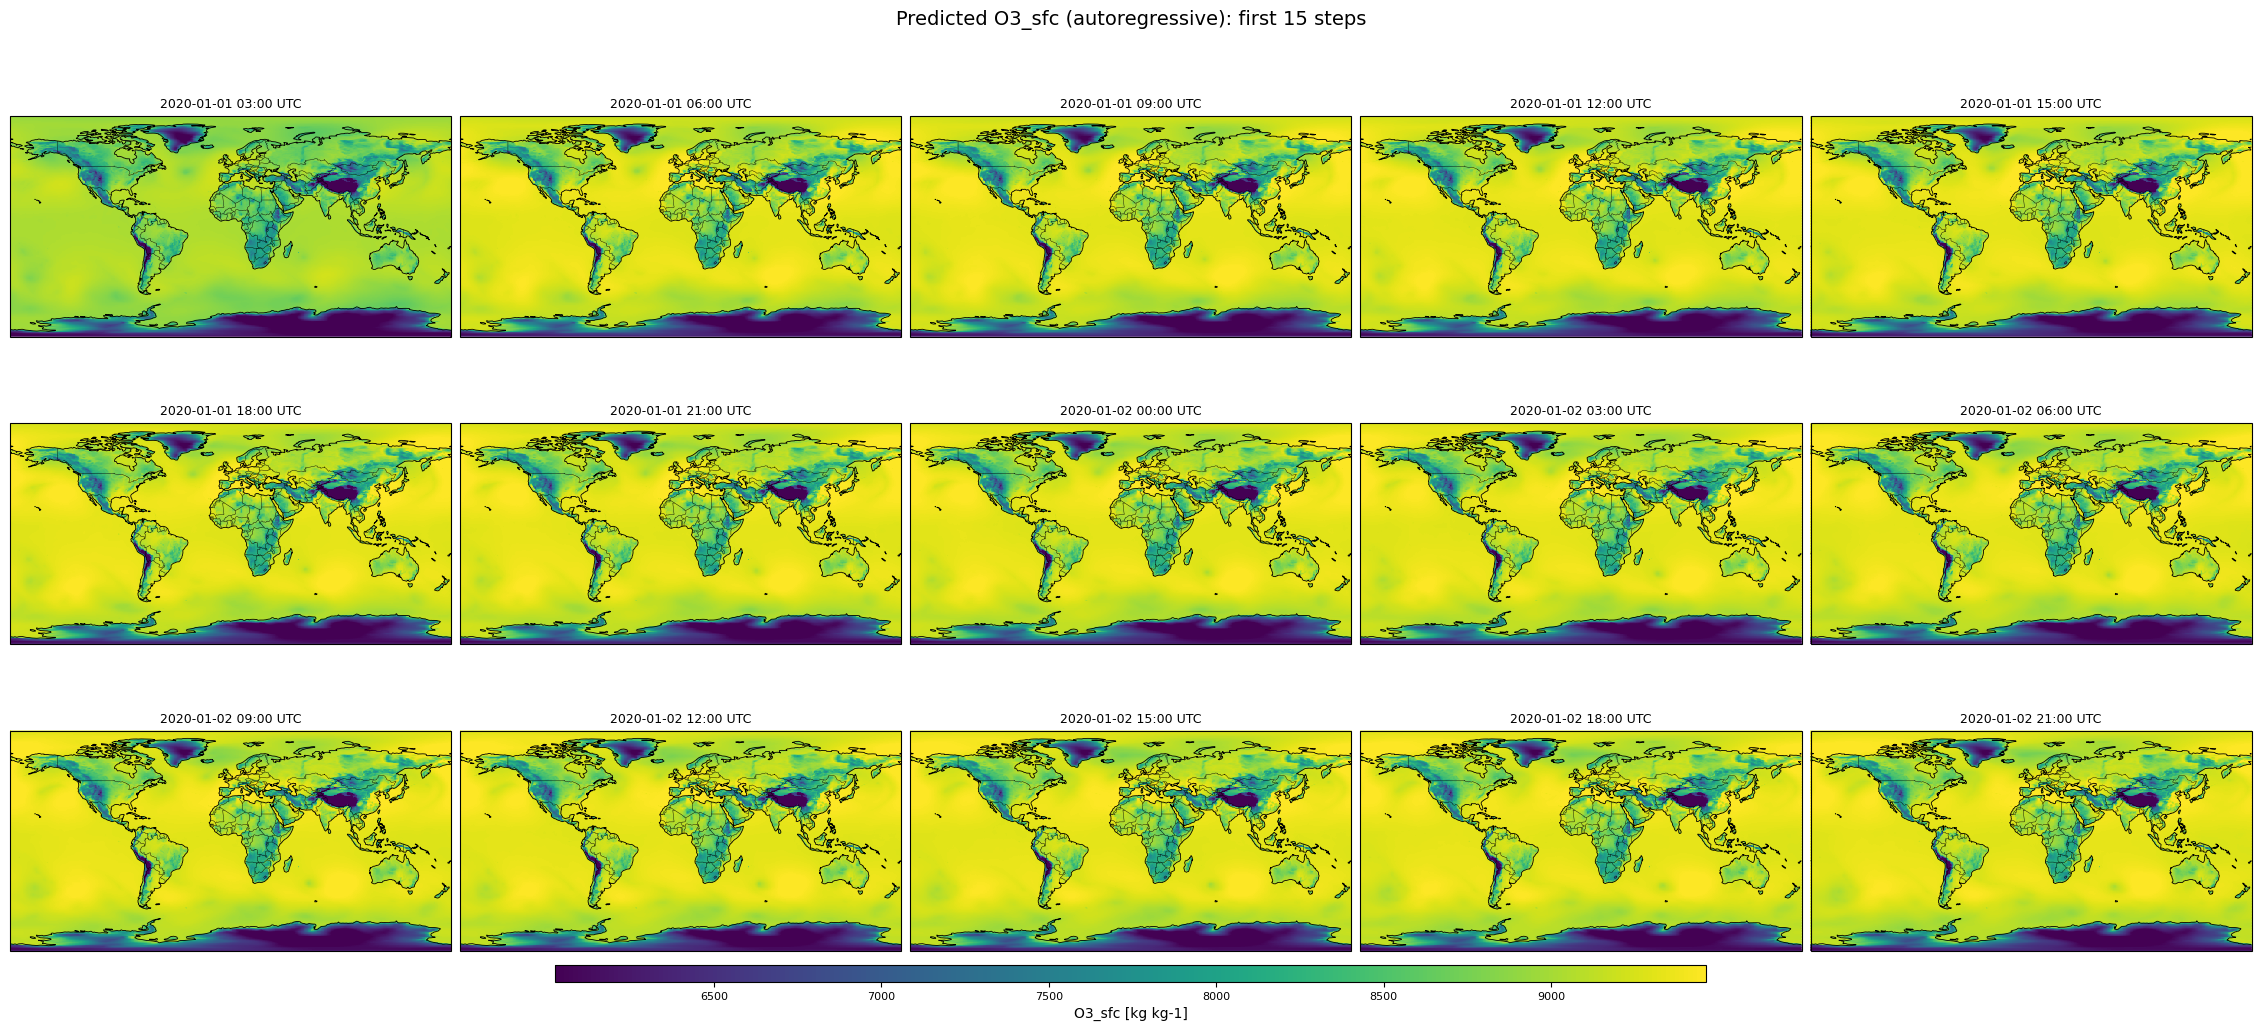

/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp/ipykernel_3496966/1024969441.py:23: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 181. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_mfdataset(
/tmp

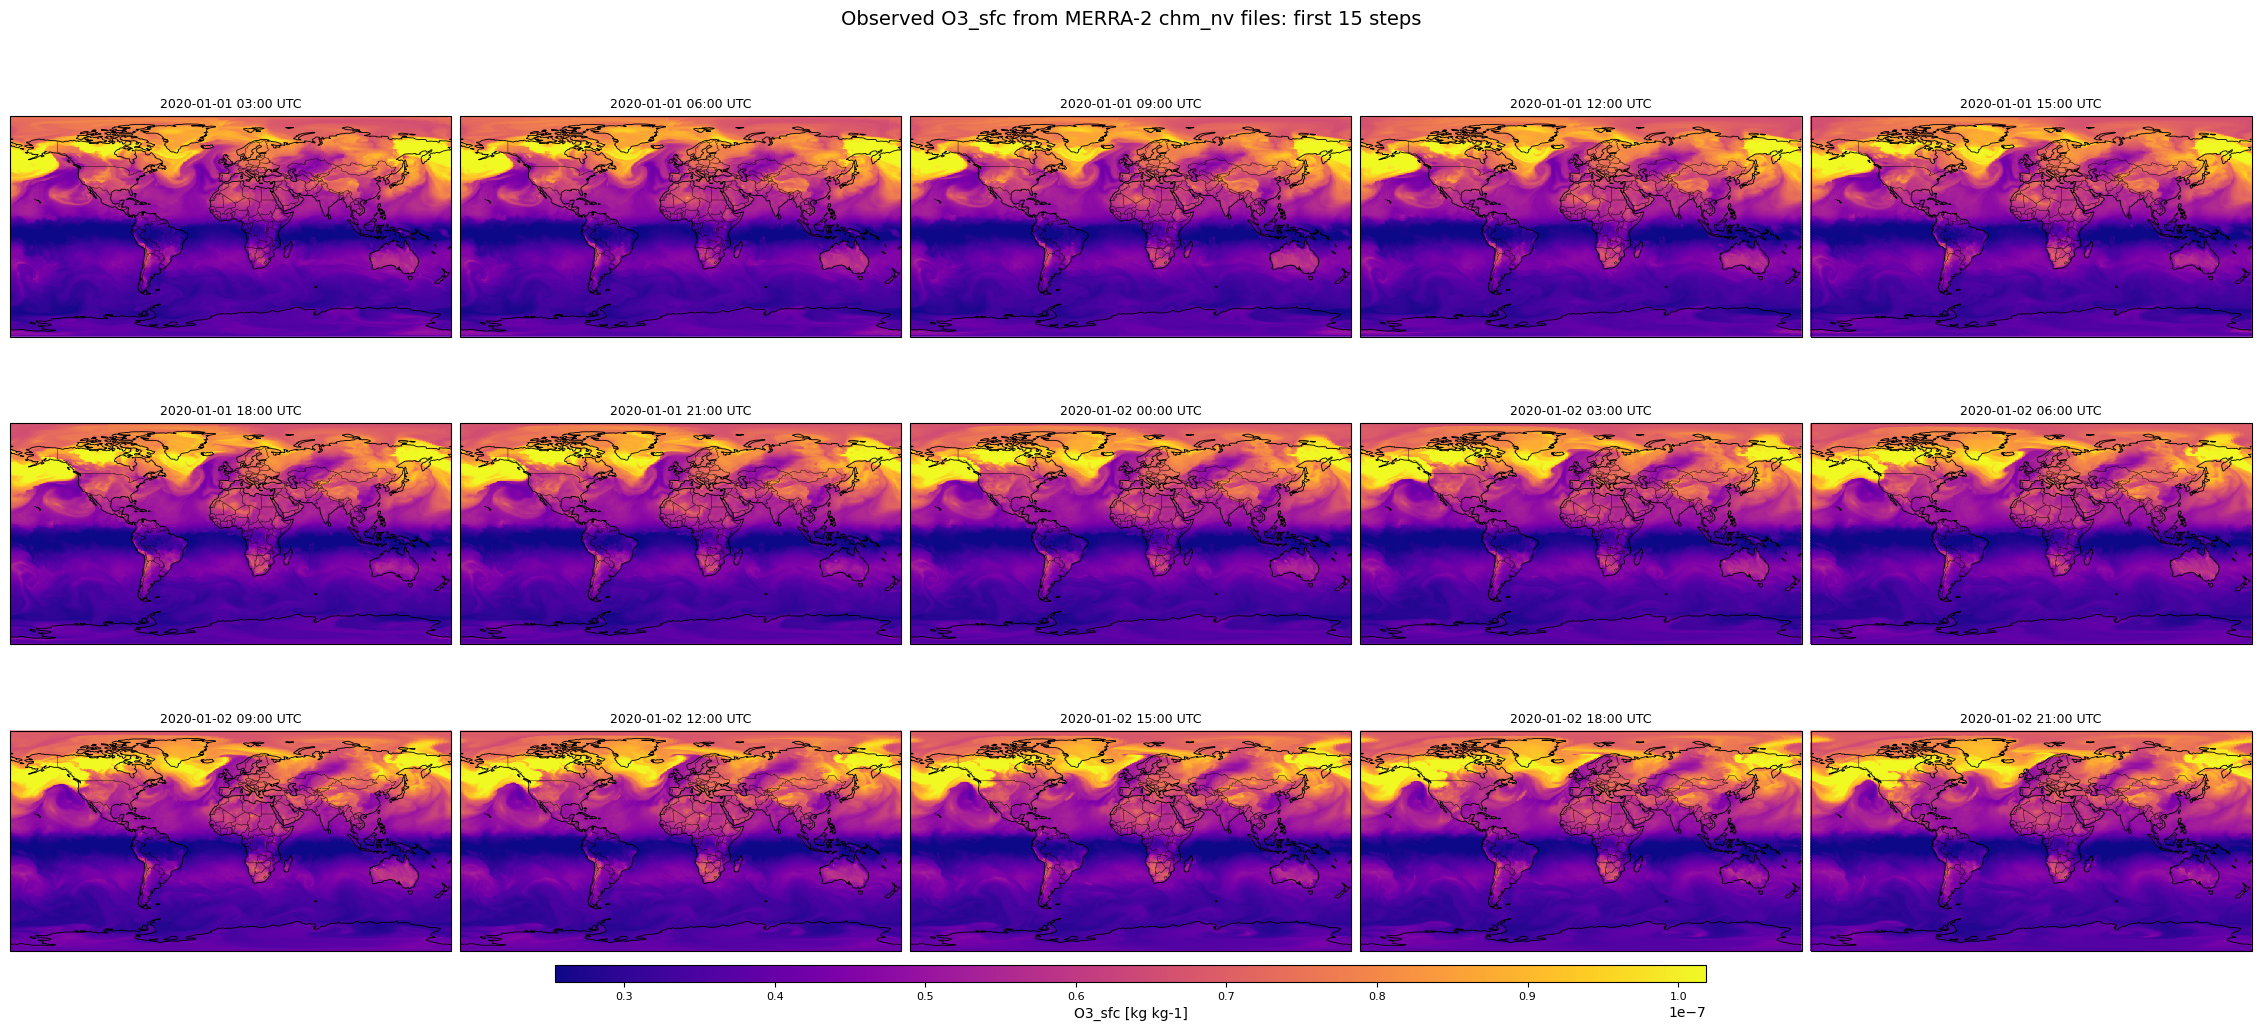

In [10]:
if is_main_process:
    import numpy as np
    import matplotlib.pyplot as plt

    try:
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
    except Exception as e:
        raise ImportError("Cartopy is required for map plotting. Install with `pip install cartopy`.") from e

    def plot_o3_maps_15(fields, lat_np, lon_np, times_np, title, units, cmap="viridis"):
        n_requested = 15
        n_total = int(fields.shape[0])
        if n_total == 0:
            print(f"{title}: no data available to plot.")
            return

        n_plot = min(n_requested, n_total)
        if n_plot < n_requested:
            print(f"{title}: only {n_total} steps available; plotting {n_plot} maps.")

        idxs = np.arange(n_plot)
        n_cols = 5
        n_rows = int(np.ceil(n_plot / n_cols))

        vmin = float(np.nanpercentile(fields[idxs], 2))
        vmax = float(np.nanpercentile(fields[idxs], 98))

        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(4.5 * n_cols, 3.4 * n_rows),
            subplot_kw={"projection": ccrs.PlateCarree()},
            constrained_layout=True,
        )
        axes = np.atleast_1d(axes).ravel()

        mappable = None
        for panel_i, t_idx in enumerate(idxs):
            ax = axes[panel_i]
            mappable = ax.pcolormesh(
                lon_np,
                lat_np,
                fields[t_idx],
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                shading="auto",
                vmin=vmin,
                vmax=vmax,
            )
            ax.coastlines(resolution="110m", linewidth=0.6)
            try:
                ax.add_feature(cfeature.BORDERS, linewidth=0.3)
            except Exception:
                pass
            ts = pd.to_datetime(times_np[t_idx]).strftime("%Y-%m-%d %H:%M UTC")
            ax.set_title(ts, fontsize=9)

        for ax in axes[n_plot:]:
            ax.set_visible(False)

        cbar = fig.colorbar(
            mappable,
            ax=axes[:n_plot],
            orientation="horizontal",
            shrink=0.95,
            fraction=0.018,
            aspect=70,
            pad=0.015,
        )
        unit_txt = units if units else "unknown"
        cbar.set_label(f"O3_sfc [{unit_txt}]")
        cbar.ax.tick_params(labelsize=8)

        fig.suptitle(f"{title}: first {n_plot} steps", fontsize=14)
        plt.show()

    # 1) Prediction maps (15)
    preds_np = preds_all.numpy() if hasattr(preds_all, "numpy") else np.asarray(preds_all)
    lat_pred = np.asarray(ds_inputs_3h["lat"].values)
    lon_pred = np.asarray(ds_inputs_3h["lon"].values)

    pred_units = ""
    if "ds_out" in locals() and "O3_sfc" in ds_out:
        pred_units = ds_out["O3_sfc"].attrs.get("units", "")
    if not pred_units and "O3_sfc" in ds_chem_3h:
        pred_units = ds_chem_3h["O3_sfc"].attrs.get("units", "")

    plot_o3_maps_15(
        fields=preds_np,
        lat_np=lat_pred,
        lon_np=lon_pred,
        times_np=time_out_dt,
        title="Predicted O3_sfc (autoregressive)",
        units=pred_units,
        cmap="viridis",
    )

    # 2) Observed O3 maps loaded directly from chemistry files (15)
    chem_paths = resolve_paths(DATA_ROOTS["chem"], "MERRA2_*inst3_3d_chm_[Nn][Vv]*.nc4")
    ds_chm = open_mfdataset_utc(chem_paths, vars_to_keep=[CHEM_VARS["O3"]])
    o3_obs = extract_surface_3d(ds_chm[CHEM_VARS["O3"]]).rename("O3_sfc")

    obs_times_all = pd.DatetimeIndex(o3_obs.time.values)
    pred_times = pd.DatetimeIndex(time_out_dt)
    matched = pred_times[pred_times.isin(obs_times_all)]

    if len(matched) > 0:
        obs_times_plot = matched[:15]
    else:
        print("No overlap with prediction timestamps; plotting first available observed times.")
        obs_times_plot = obs_times_all[:15]

    o3_obs_plot = o3_obs.sel(time=obs_times_plot).load()
    obs_np = np.asarray(o3_obs_plot.values)
    lat_obs = np.asarray(o3_obs_plot["lat"].values)
    lon_obs = np.asarray(o3_obs_plot["lon"].values)
    obs_units = o3_obs_plot.attrs.get("units", "")

    plot_o3_maps_15(
        fields=obs_np,
        lat_np=lat_obs,
        lon_np=lon_obs,
        times_np=np.asarray(o3_obs_plot.time.values),
        title="Observed O3_sfc from MERRA-2 chm_nv files",
        units=obs_units,
        cmap="plasma",
    )
